<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Librerías de Visualización y EDA Avanzado con Seaborn 🎨
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Programación para Ciencia de Datos
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 04
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>


---
## EDA con Datos Complejos 📊

Vamos a utilizar un conjunto de datos diferente. Ahora cargaremos un dataset que consiste en las calificaciones obtenidas por estudiantes en varias asignaturas.

**El objetivo:** Comprender la influencia del origen de los padres, la preparación para los exámenes, el almuerzo, etc., en el rendimiento de los estudiantes.

* 📥 **Fuente:** [Kaggle - Students Performance in Exams](https://www.kaggle.com/spscientist/students-performance-in-exams)

> *Nota:* Si visitas la fuente original, descubrirás que este es un conjunto de datos ficticio creado específicamente para propósitos de entrenamiento en Ciencia de Datos.


---
### 1. Carga y Limpieza Inicial

In [1]:
import os
import urllib.parse
import urllib.request
import pandas as pd

# 🚀 Función de utilidad para cargar datasets de forma segura (Local o Google Colab)
def load_dataset(filename, module_name="04 - EDA"):
    candidates = [
        f"data/{filename}",
        f"{module_name}/data/{filename}",
        filename
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
            
    os.makedirs("data", exist_ok=True)
    target_path = f"data/{filename}"
    encoded_module = urllib.parse.quote(module_name)
    encoded_file = urllib.parse.quote(filename)
    url_main = f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/{encoded_module}/data/{encoded_file}"
    url_master = f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/master/{encoded_module}/data/{encoded_file}"
    
    print(f"📥 Descargando dataset '{filename}' desde el repositorio oficial...")
    try:
        urllib.request.urlretrieve(url_main, target_path)
    except Exception:
        urllib.request.urlretrieve(url_master, target_path)
    print(f"✅ Dataset '{filename}' cargado exitosamente.")
    return target_path

# Carga del dataset StudentsPerformance
file_path = load_dataset('StudentsPerformance.csv', '04 - EDA')
df = pd.read_csv(file_path)
print('Dimensiones:', df.shape)
df.head()


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   gender    1000 non-null   str  
 1   group     1000 non-null   str  
 2   parental  1000 non-null   str  
 3   lunch     1000 non-null   str  
 4   course    1000 non-null   str  
 5   math      1000 non-null   int64
 6   reading   1000 non-null   int64
 7   writing   1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [3]:
df.head()

,gender,group,parental,lunch,course,math,reading,writing
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### 1.1 Transformación de Texto (`Series.str`)
📚 **Documentación:** [Series.str](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.html)

Las funciones vectorizadas de strings (cadenas de texto) nos permiten modificar columnas enteras de manera muy eficiente. Por ejemplo, podemos simplificar los valores de los grupos para quedarnos solo con la letra ('group B' -> 'B').

In [4]:
print("Originales:", df['group'].unique().tolist())

# Extraemos solo el último caracter de la cadena
df['group'] = df['group'].str[-1]

print("Simplificados:", df['group'].unique().tolist())

Originales: ['group B', 'group C', 'group A', 'group D', 'group E']
Simplificados: ['B', 'C', 'A', 'D', 'E']


#### 1.2 Transformación con Funciones (`Series.apply`)
📚 **Documentación:** [Series.apply](https://pandas.pydata.org/docs/reference/api/pandas.Series.apply.html)

Podemos invocar una función personalizada sobre los valores de una Serie. Por ejemplo, convirtiendo los valores de texto de la columna `course` ('none'/'completed') en valores booleanos (Falso/Verdadero).

In [5]:
print("Valores originales del curso:", df['course'].unique())

if 'completed' in df['course'].unique().tolist():
    # Aplicamos una función lambda para transformar a 1 y 0
    df['course'] = df['course'].apply(lambda x: 1 if x == 'completed' else 0)
    # Transformamos el tipo de dato de la columna a Booleano
    df['course'] = df['course'].astype(bool)

print("Valores booleanos:", df['course'].unique())
df.head()

Valores originales del curso: <StringArray>
['none', 'completed']
Length: 2, dtype: str
Valores booleanos: [False  True]


,gender,group,parental,lunch,course,math,reading,writing
0,female,B,bachelor's degree,standard,False,72,72,74
1,female,C,some college,standard,True,69,90,88
2,female,B,master's degree,standard,False,90,95,93
3,male,A,associate's degree,free/reduced,False,47,57,44
4,male,C,some college,standard,False,76,78,75


#### 1.3 Valores Faltantes (Missings)
Siempre debemos verificar si hay valores nulos en nuestro dataset.

In [6]:
df.isna().sum()

,0
gender,0
group,0
parental,0
lunch,0
course,0
math,0
reading,0
writing,0



---
### 2. Formulando Preguntas 🤔

El Análisis Exploratorio de Datos se trata de hacerle preguntas al dataset:

1. ¿El género afecta los puntajes en matemáticas?
2. ¿Los puntajes de lectura y escritura afectan los puntajes en matemáticas?
3. ¿Un grupo étnico tiene un rendimiento mejor en matemáticas que el resto?
4. ¿El nivel educativo de los padres afecta los puntajes en matemáticas?

Para responder esto, comencemos a revisar la distribución de los puntajes con estadística descriptiva.

In [7]:
df[['reading','math']].describe()

,reading,math
count,1000.000000,1000.00000
mean,69.169000,66.08900
std,14.600192,15.16308
min,17.000000,0.00000
25%,59.000000,57.00000
50%,70.000000,66.00000
75%,79.000000,77.00000
max,100.000000,100.00000


Es muy poco común ver un 0 en los puntajes de un examen. Pero si miramos el `min` de matemáticas, vemos un 0. ¡Identifiquemos a este estudiante!

In [8]:
df[df['math'] == 0]

,gender,group,parental,lunch,course,math,reading,writing
59,female,C,some high school,free/reduced,False,0,17,10


*(Pregunta abierta para pensar: ¿Parece posible este registro? ¿Por qué? Un puntaje de 0 en matemáticas con 17 en lectura y 10 en escritura nos habla de un examen que probablemente fue abandonado o anulado).* 

---
### 3. Histogramas y Estimación de Densidad Kernel (KDE) 📉

📚 **Documentación:** 
- [seaborn.histplot()](https://seaborn.pydata.org/generated/seaborn.histplot.html)
- [seaborn.kdeplot()](https://seaborn.pydata.org/generated/seaborn.kdeplot.html)

Podemos visualizar la distribución usando histogramas y subgráficos de Matplotlib.

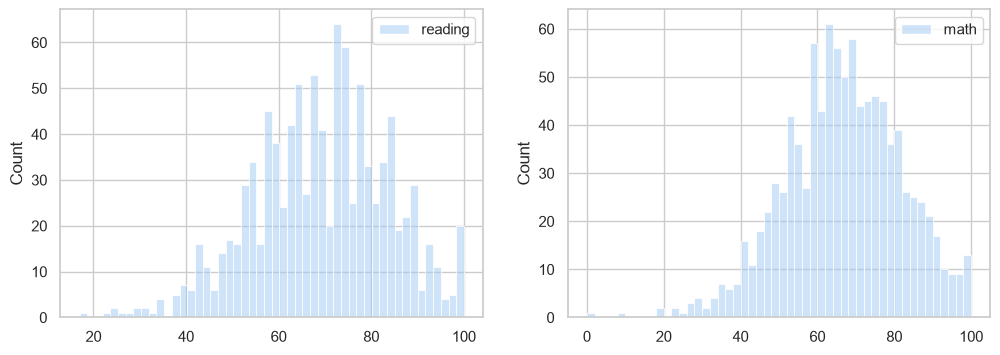

In [9]:
plt.figure(figsize=(12, 4))
sns.histplot(df[['reading']], bins=50, ax=plt.subplot(121), palette=palette)
sns.histplot(df[['math']], bins=50, ax=plt.subplot(122), palette=palette);

Pero sabiendo que, por defecto, `sns.histplot` agrupa todas las características en el mismo gráfico, podríamos simplificarlo enormemente pasándole ambas variables simultáneamente.

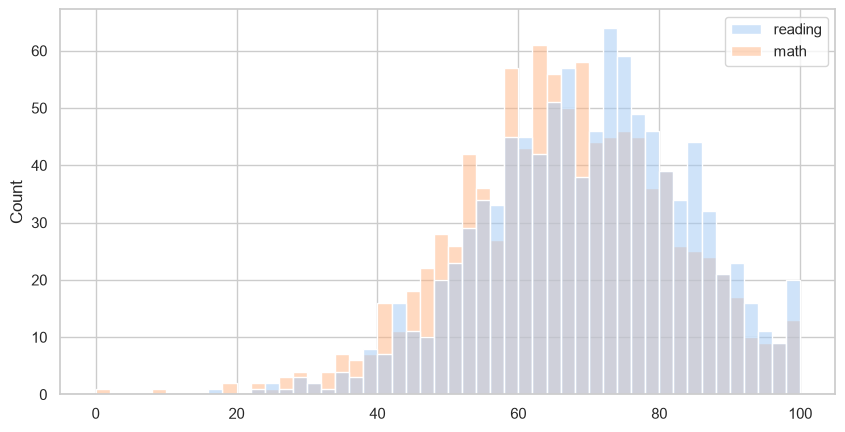

In [10]:
sns.histplot(df[['reading', 'math']], bins=50, palette=palette);

#### 3.1 Kernel Density Estimate (KDE)
Un gráfico de Estimación de Densidad Kernel (KDE) es una forma no paramétrica de estimar la función de densidad de probabilidad de una variable continua. Proporciona una representación suave y continua, similar a un histograma, pero sin tener que discretizar los datos en contenedores (bins).

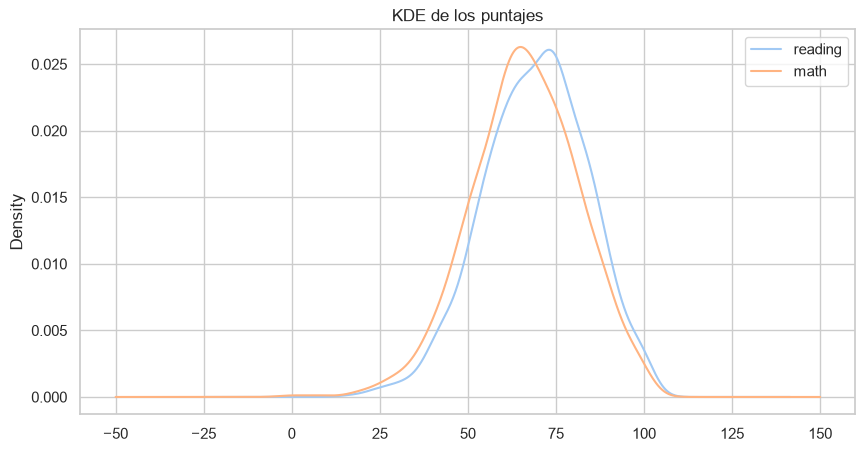

In [11]:
df[['reading', 'math']].plot.kde()
plt.title('KDE de los puntajes');

Seaborn permite fusionar ambas visualizaciones fácilmente habilitando el parámetro `kde=True`.

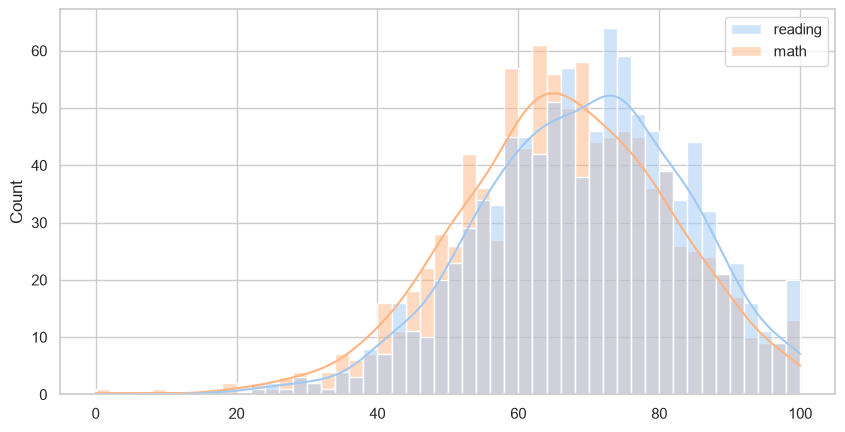

In [12]:
sns.histplot(df[['reading', 'math']], bins=50, kde=True, palette=palette);

---
##### 🛠️ Práctica 1: Evaluando la asimetría con KDE
Usa Seaborn para graficar exclusivamente un KDE (con `sns.kdeplot`) de los tres puntajes: `math`, `reading`, y `writing` en la misma gráfica. 
Agrega un sombreado debajo de la línea activando el parámetro `fill=True`.

¿Cuál de las 3 áreas tiene los puntajes más altos (curva desplazada a la derecha)?

In [ ]:
# Escribe tu código aquí
# sns.kdeplot(data=..., fill=...)

<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
sns.kdeplot(data=df[['math', 'reading', 'writing']], fill=True, palette=palette)
plt.title('Comparativa de todos los puntajes')
```
La curva de Reading (y parcialmente Writing) están más desplazadas hacia la derecha que Math, indicando que a los estudiantes les va mejor en esas asignaturas.
</details>


---
### 4. Evoluciones del BoxPlot 📦
A primera vista, las distribuciones parecen similares. Como vimos, la de matemáticas parece estar ligeramente desplazada hacia abajo. Confirmémoslo con Diagramas de Caja.

📚 **Documentación:** 
- [seaborn.boxplot()](https://seaborn.pydata.org/generated/seaborn.boxplot.html)
- [seaborn.boxenplot()](https://seaborn.pydata.org/generated/seaborn.boxenplot.html)
- [seaborn.violinplot()](https://seaborn.pydata.org/generated/seaborn.violinplot.html)

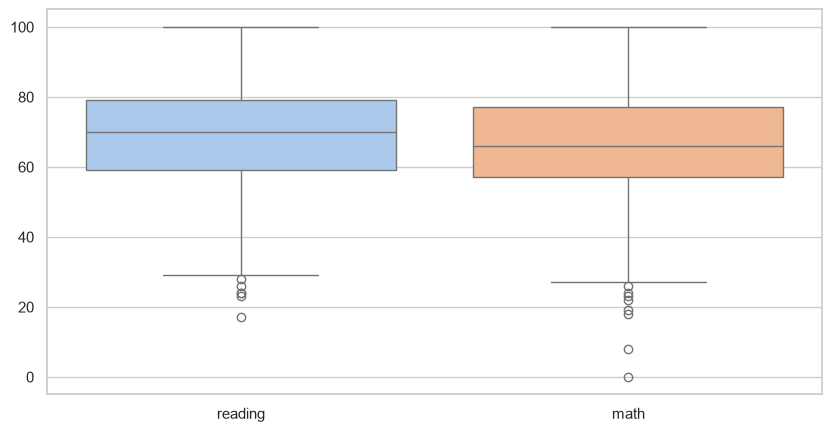

In [13]:
sns.boxplot(data=df[['reading', 'math']], palette=palette);

#### 4.1 Boxenplots (Letter values)
Un boxenplot proporciona información adicional sobre la forma de la distribución, particularmente en las colas (extremos). Es similar a un boxplot pero muestra cuantiles adicionales, resultando en una representación más detallada en datasets grandes.

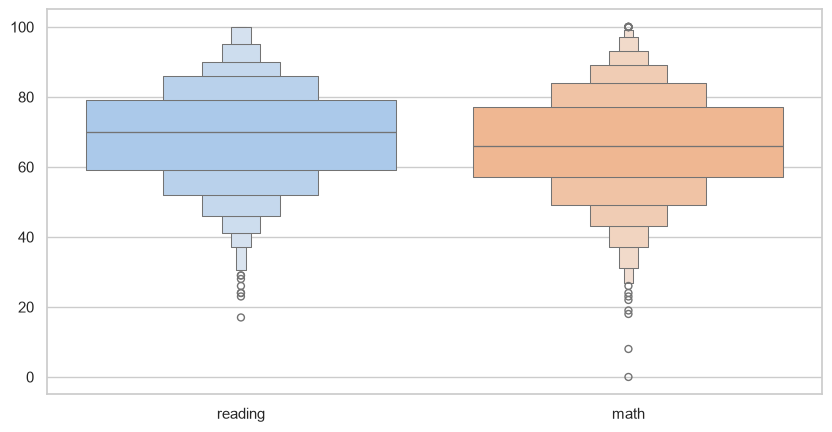

In [14]:
sns.boxenplot(data=df[['reading', 'math']], palette=palette);

#### 4.2 Violinplots
Un violin plot combina los aspectos de un Boxplot y un KDE. Es excelente para visualizar la distribución multimodal (cuando hay varias "jorobas" de datos) a través de diferentes categorías.

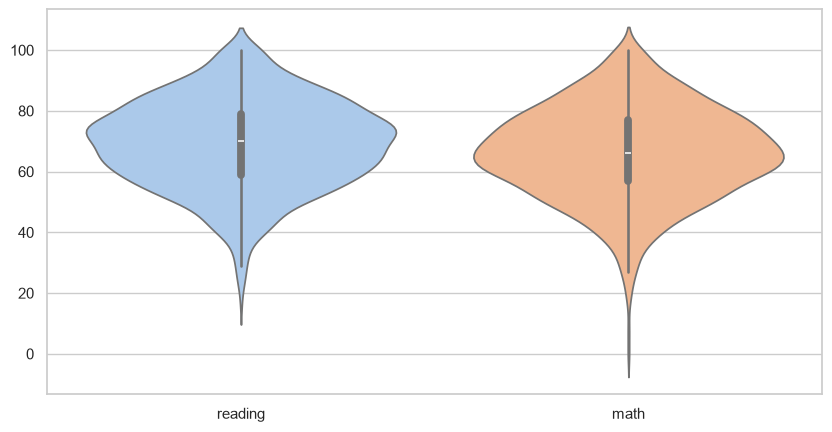

In [15]:
sns.violinplot(data=df[['reading', 'math']], palette=palette);

---
### 5. Correlaciones y Diagramas de Dispersión 🔗

¿Qué hay de la relación entre los puntajes? ¿Interactúan entre sí? (Si soy bueno en lectura, ¿soy bueno en matemáticas?).

¡El Scatterplot al rescate!

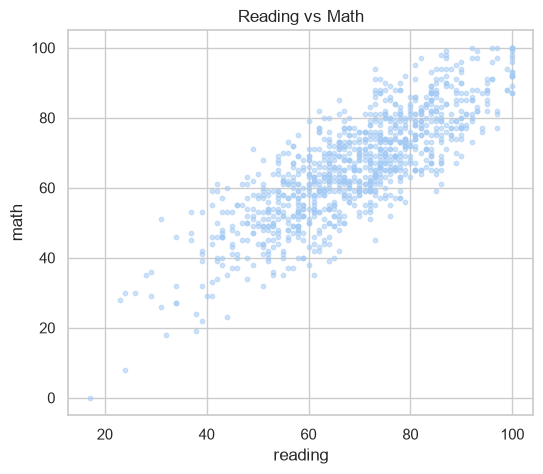

In [16]:
df.plot.scatter(x='reading', y='math', s=10, alpha=.5, figsize=(6,5))
plt.title('Reading vs Math');

Hay una clara correlación visual. A medida que aumenta el puntaje de lectura, el puntaje de matemáticas tiende a aumentar.

#### 5.1 Matrices de Correlación
📚 **Documentación:** [pandas.DataFrame.corr()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html)

Pandas implementa el método `corr()` que calcula la correlación por pares de todas las columnas (excluyendo valores nulos).

In [17]:
df[['reading', 'math']].corr()

,reading,math
reading,1.00000,0.81758
math,0.81758,1.00000


Ofrece distintos métodos matemáticos. Pearson y Spearman son los más utilizados.

In [18]:
for method in ['pearson', 'kendall', 'spearman']:
    # iloc[0,1] nos extrae el valor específico de correlación cruzada de la matriz resultante
    corr = df[['reading', 'math']].corr(method=method).iloc[0, 1]
    print(f'Correlación de {method.capitalize()}: {corr:.3f}')

Correlación de Spearman: 0.804


Hemos confirmado matemáticamente que hay una **fuerte correlación lineal (0.81)** entre los puntajes de lectura y matemáticas.

Veamos la correlación de *todas* las variables numéricas:

In [19]:
df.corr(numeric_only=True)

,course,math,reading,writing
course,1.000000,0.177702,0.241780,0.312946
math,0.177702,1.000000,0.817580,0.802642
reading,0.241780,0.817580,1.000000,0.954598
writing,0.312946,0.802642,0.954598,1.000000


**¡Wow!** La lectura y la escritura tienen una correlación extrema de 0.95. Prácticamente miden lo mismo.

Podemos visualizar todas estas relaciones usando el método mágico de Seaborn: **Pairplot**.

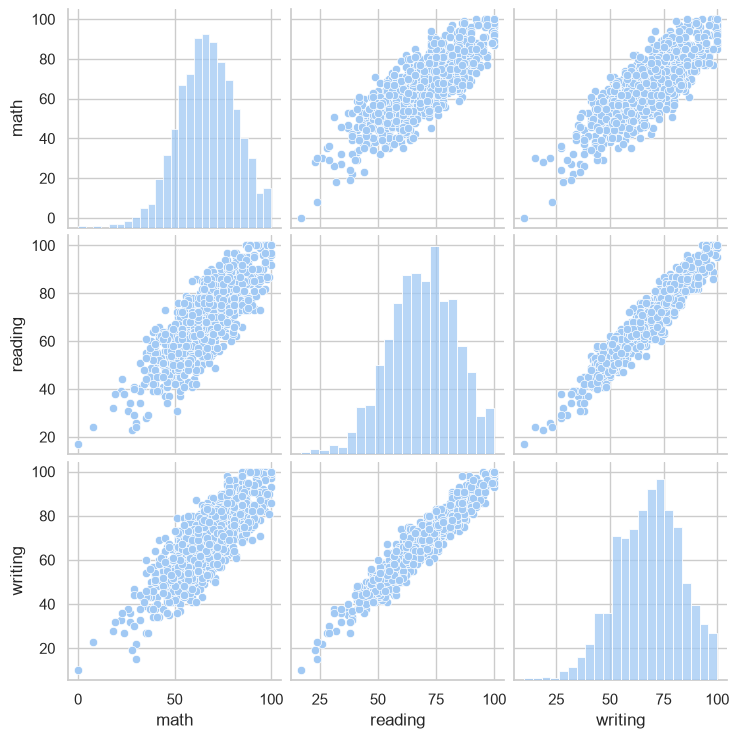

In [20]:
# sns.pairplot crea una matriz de scatter plots para cruzar TODAS las variables
sns.pairplot(df.select_dtypes('number'), palette=palette);

#### 5.2 Mapas de Calor (Heatmaps)
📚 **Documentación:** [seaborn.heatmap()](https://seaborn.pydata.org/generated/seaborn.heatmap.html)

Un mapa de calor traza datos rectangulares como una matriz codificada por colores. Es la herramienta definitiva y preferida en la industria para visualizar correlaciones.

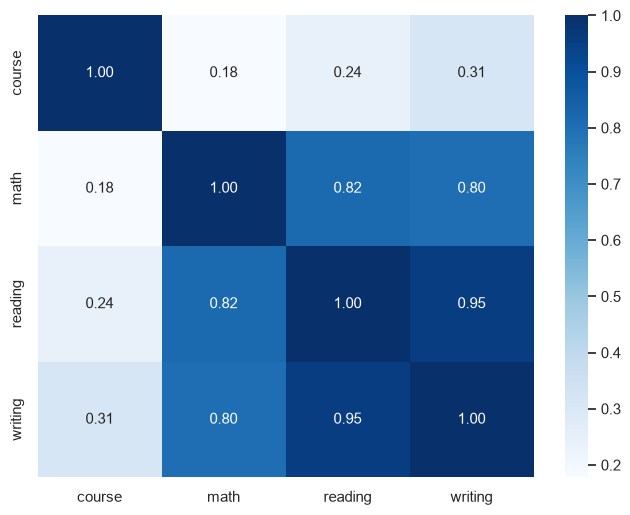

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# annot=True pinta los números encima.
# fmt='.2f' restringe los decimales a 2.
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='Blues', ax=ax);

---
##### 🛠️ Práctica 2: Analizando al enemigo (Variables dummy)
A menudo queremos correlacionar variables que no son numéricas (como el género). Para eso, tenemos que convertirlas en variables *Dummy* (unos y ceros).

El código de abajo crea dos columnas (`is_female` y `is_male`). Usa el método `DataFrame.corrwith()` sobre las columnas de puntaje (`['math', 'reading', 'writing']`) para correlacionarlas contra la nueva serie `df['is_female']`.

¿Las mujeres tienen ventaja en alguna asignatura?

In [22]:
# Creamos variables Dummy
df['is_female'] = df['gender'].apply(lambda x: 1 if x == 'female' else 0).astype(float)
df['is_male'] = df['gender'].apply(lambda x: 1 if x == 'male' else 0).astype(float)

# Escribe tu código aquí
# ...corrwith(...)

<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
correlacion_femenina = df[['math', 'reading', 'writing']].corrwith(df['is_female'])
print(correlacion_femenina)

# Las correlaciones son positivas y considerables en lectura (0.24) y escritura (0.30).
# Sin embargo, es negativa en matemáticas (-0.16).
# Matemáticamente, en este dataset ficticio, ser mujer está positivamente correlacionado 
# con mejores puntajes en lenguaje, pero negativamente correlacionado con matemáticas.
```
</details>


---
### 6. Variables Derivadas y Gráficos Categóricos 📊

Respondamos la pregunta: **¿Quiénes aprueban matemáticas?** 
Vamos a crear una variable que indique si un estudiante aprobó (superó el puntaje 40).

In [23]:
approval_threshold = 40
df['approved'] = (df['math'] >= approval_threshold).astype(int)
df.head()

,gender,group,parental,lunch,course,math,reading,writing,is_female,is_male,approved
0,female,B,bachelor's degree,standard,False,72,72,74,1.0,0.0,1
1,female,C,some college,standard,True,69,90,88,1.0,0.0,1
2,female,B,master's degree,standard,False,90,95,93,1.0,0.0,1
3,male,A,associate's degree,free/reduced,False,47,57,44,0.0,1.0,1
4,male,C,some college,standard,False,76,78,75,0.0,1.0,1


#### 6.1 Gráficos Circulares (Pie Plots)
Nota rápida: Seaborn **NO** incluye un método para graficar diagramas de pastel porque los estadísticos consideran que los humanos somos muy malos calculando áreas angulares. 

Siempre prefieren gráficos de barras. Si quieres un pie plot, usa Pandas directamente:

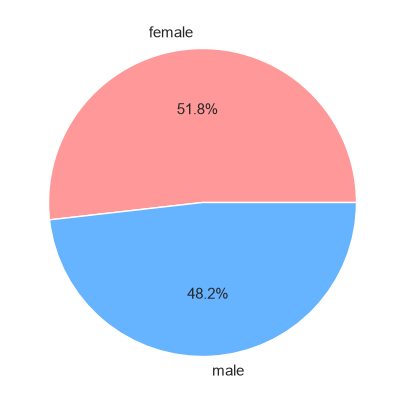

In [24]:
df['gender'].value_counts(normalize=True).plot.pie(figsize=(5, 5), autopct='%1.1f%%', colors=['#ff9999','#66b3ff']);

#### 6.2 Gráficos de Conteo (Countplot y Barplot)
Seaborn tiene un método especial para graficar el conteo de variables categóricas.

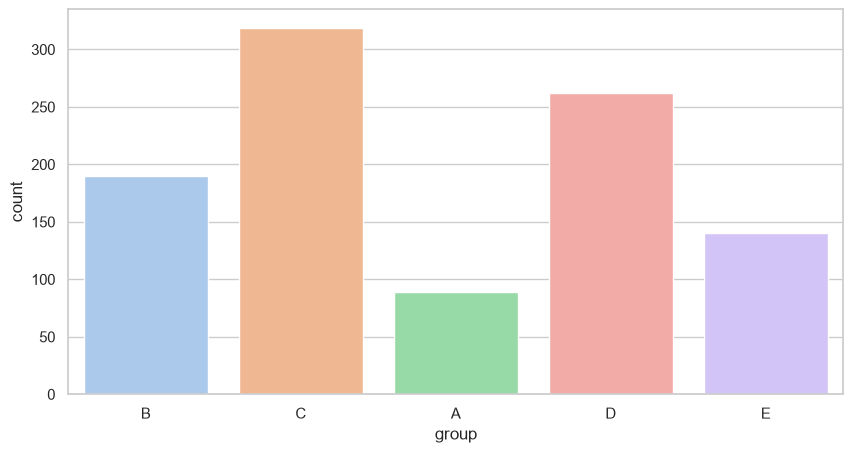

In [25]:
sns.countplot(data=df, x='group', palette=palette);

El problema es que `countplot` no tiene un parámetro para **normalizar** (mostrar en porcentajes) los valores de manera simple.

Para plotear proporciones porcentuales normalizadas en Seaborn, a menudo es mejor usar `barplot` pasando los datos agrupados por Pandas:

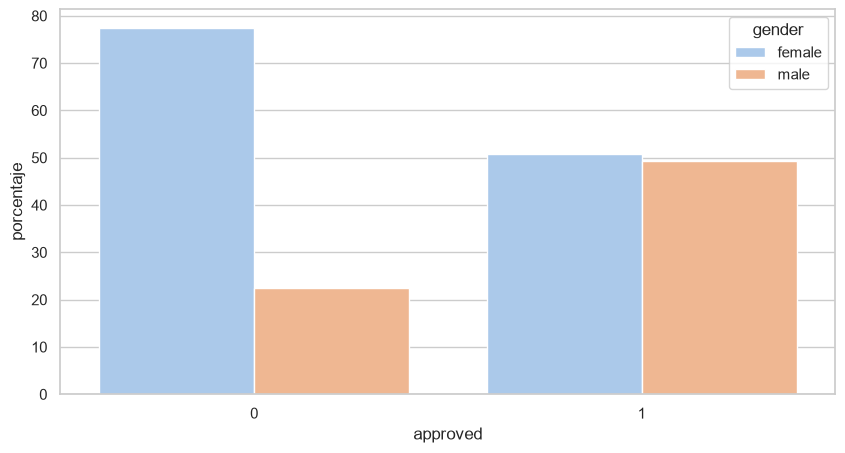

In [26]:
# Calculamos la proporción porcentual
tmp = (df.groupby('approved')['gender'].value_counts(normalize=True).to_frame().rename(columns={'proportion': 'porcentaje'}) * 100).reset_index()

sns.barplot(data=tmp, x='approved', y='porcentaje', hue='gender', palette=palette);

Observamos que, del pequeño porcentaje de personas que reprobaron matemáticas (`approved=0`), la inmensa mayoría eran mujeres. Sin embargo, en el gran porcentaje de personas que sí aprobaron (`approved=1`), la proporción es 50/50.

---
### 7. El poder del Unpivot + FacetGrid 🌟

Como vimos en la sesión pasada, `pandas.melt()` es un método poderoso para deserializar (unpivot) un dataframe. Si hacemos las cosas fáciles de leer para Seaborn, Seaborn hará que los gráficos sean fáciles de leer para nosotros.

In [27]:
# Seleccionamos columnas numéricas
score_cols = ['math', 'reading', 'writing']
id_vars = [c for c in df.columns if c not in score_cols]

melted = pd.melt(df, id_vars=id_vars, value_vars=score_cols, var_name='skill', value_name='score')
melted.head()

,gender,group,parental,lunch,course,is_female,is_male,approved,skill,score
0,female,B,bachelor's degree,standard,False,1.0,0.0,1,math,72
1,female,C,some college,standard,True,1.0,0.0,1,math,69
2,female,B,master's degree,standard,False,1.0,0.0,1,math,90
3,male,A,associate's degree,free/reduced,False,0.0,1.0,1,math,47
4,male,C,some college,standard,False,0.0,1.0,1,math,76


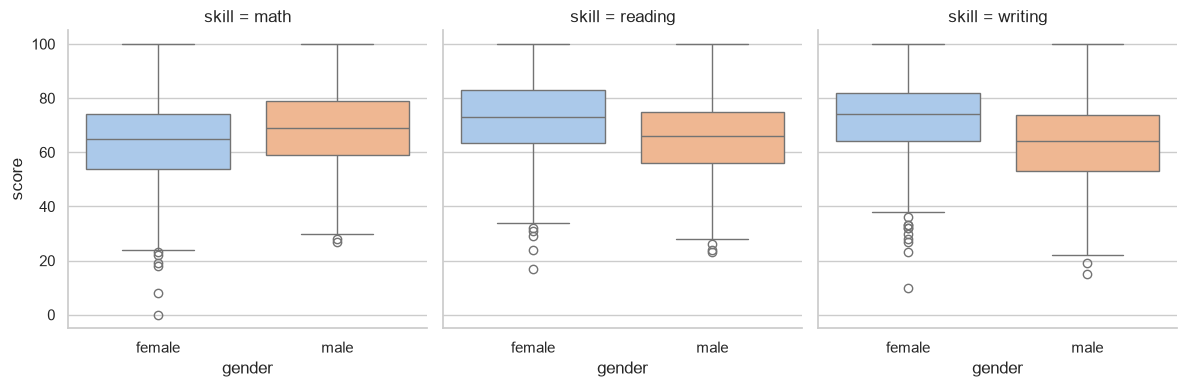

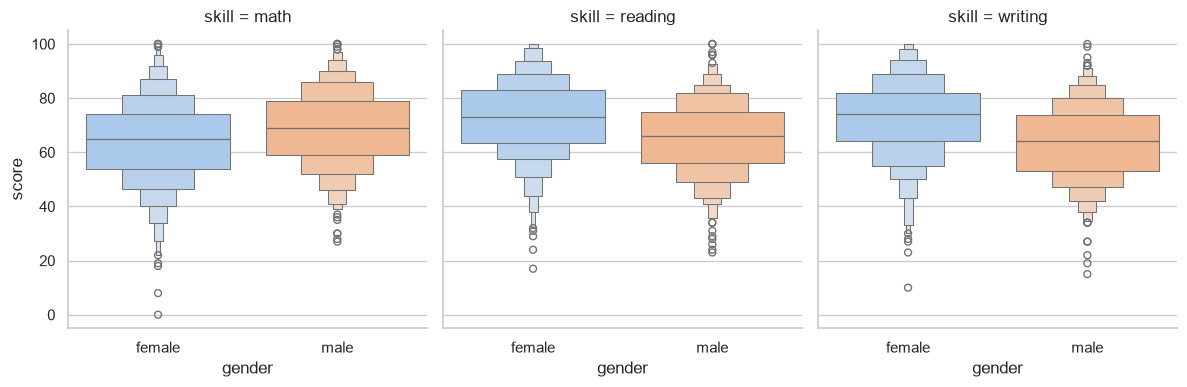

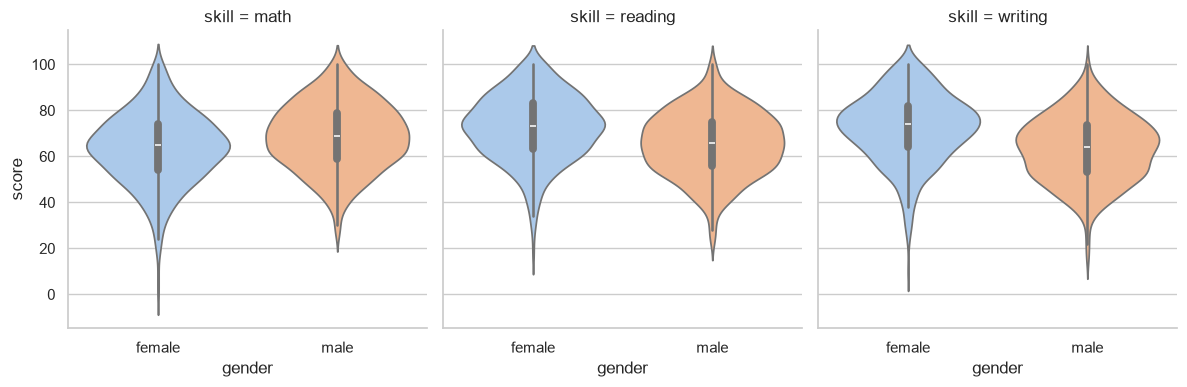

In [28]:
# Usamos FacetGrid para iterar sobre TODOS los métodos de dibujo (Box, Boxen, Violin)
for func in [sns.boxplot, sns.boxenplot, sns.violinplot]:
    g = sns.FacetGrid(melted, col="skill", height=4)
    g.map(func, 'gender', 'score', order=['female', 'male'], palette=palette);

Este último bloque de código resume el inmenso poder analítico y visual del Análisis Exploratorio de Datos usando la combinación **Pandas + Seaborn**. ¡En 4 líneas de código generamos 9 gráficos que demuestran todas las variaciones estadísticas de género cruzadas por todas las áreas de estudio!


---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Programación para Ciencia de Datos</i>
  </p>
</div>
